In [1]:
#used library list
import time
import numpy as np
import librosa
import pandas as pd
from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score
import librosa.display
import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
rootDir = ''

# testcse = ['biden-original.wav', 'linus-original.wav','margot-original.wav','musk-original.wav','obama-original.wav','ryan-original.wav','taylor-original.wav','trump-original.wav']
# fake_audio = rootDir+'/AUDIO/FAKE/biden-to-trump.wav'
fake_audio = rootDir+ '/AUDIO/REAL/biden-original.wav'
real_audio = rootDir+'/AUDIO/REAL/biden-original.wav'
# fake_audio = rootDir + '/DEMONSTRATION/linus-to-musk-DEMO.mp3'
# real_audio = rootDir + '/DEMONSTRATION/linus-original-DEMO.mp3'

# Load the audio files
y_fake, sr_fake = librosa.load(fake_audio)
y_real, sr_real = librosa.load(real_audio)

# Create a figure with two subplots
plt.figure(figsize=(15, 5))

# Plot the first audio file
plt.subplot(2, 1, 1)
librosa.display.waveshow(y_fake, sr=sr_fake)
plt.title('Fake Audio Waveform')
plt.xlabel('Time')
plt.ylabel('Amplitude')

# Plot the second audio file
plt.subplot(2, 1, 2)
librosa.display.waveshow(y_real, sr=sr_real)
plt.title('Real Audio Waveform')
plt.xlabel('Time')
plt.ylabel('Amplitude')

# Display the plots
plt.tight_layout()
plt.show()

/var/folders/zw/l_80xyhn3kvg9y1rl4kjzq080000gn/T/ipykernel_48662/377687980.py:11: UserWarning: PySoundFile failed. Trying audioread instead.
  y_fake, sr_fake = librosa.load(fake_audio)
/opt/anaconda3/envs/voice-deepfake-env/lib/python3.10/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


FileNotFoundError: [Errno 2] No such file or directory: '/AUDIO/REAL/biden-original.wav'

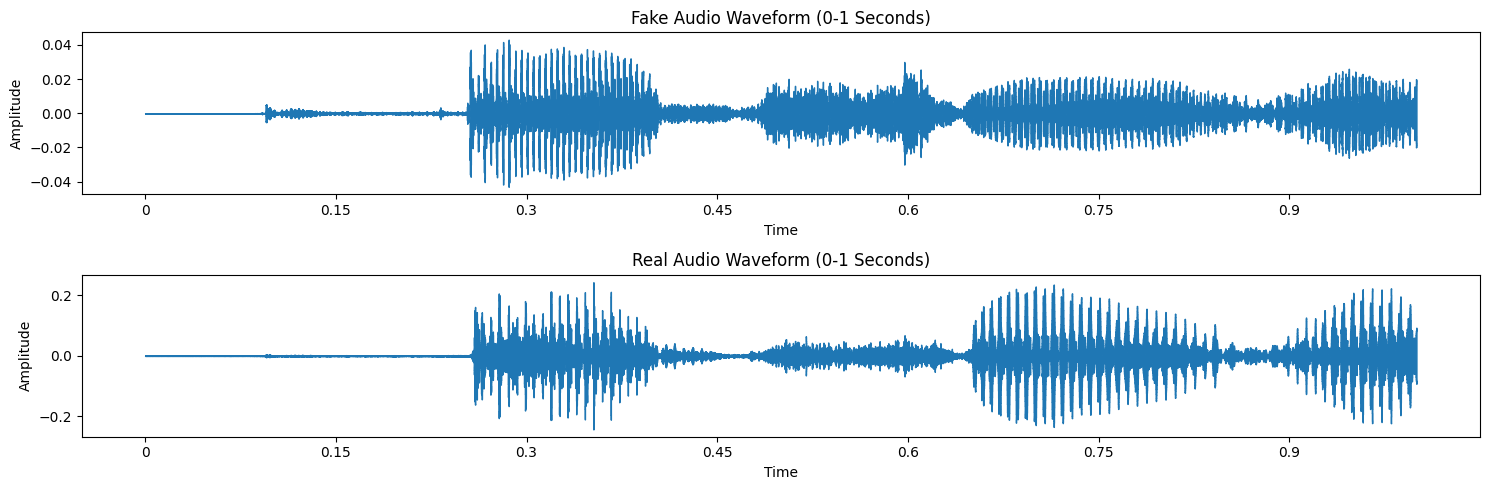

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Define the file paths
rootDir = 'drive/MyDrive/이희재s'
fake_audio = rootDir + '/AUDIO/REAL/taylor-original.wav'
real_audio = rootDir + '/AUDIO/FAKE/taylor-to-biden.wav'

# Load the first 5 seconds of the audio files
y_fake, sr_fake = librosa.load(fake_audio, duration=1.0)
y_real, sr_real = librosa.load(real_audio, duration=1.0)

# Create a figure with two subplots
plt.figure(figsize=(15, 5))

# Plot the first audio file
plt.subplot(2, 1, 1)
librosa.display.waveshow(y_fake, sr=sr_fake)
plt.title('Fake Audio Waveform (0-1 Seconds)')
plt.xlabel('Time')
plt.ylabel('Amplitude')

# Plot the second audio file
plt.subplot(2, 1, 2)
librosa.display.waveshow(y_real, sr=sr_real)
plt.title('Real Audio Waveform (0-1 Seconds)')
plt.xlabel('Time')
plt.ylabel('Amplitude')

# Display the plots
plt.tight_layout()
plt.show()


In [ ]:
pass
# for x in testcse:
#     dir_real = rootDir + '/AUDIO/REAL/' + x
#     r_y, r_sr = librosa.load(dir_real)
#     r_chr = librosa.feature.chroma_stft(y=r_y, sr = r_sr)
#     r_rms = librosa.feature.rms(y=r_y)
#     r_cent = librosa.feature.spectral_centroid(y=r_y, sr = r_sr)
#     print('============================================================')
#     print(r_chr[0][0])
#     print('--------------------------------')
#     print(r_rms[0][0])
#     print('--------------------------------')
#     print(r_cent[0][0])
# else:
#     dir_real=rootDir + '/DEMONSTRATION/linus-original-DEMO.mp3'
#     r_y, r_sr = librosa.load(dir_real)
#     r_chr = librosa.feature.chroma_stft(y=r_y, sr = r_sr)
#     r_rms = librosa.feature.rms(y=r_y)
#     r_cent = librosa.feature.spectral_centroid(y=r_y, sr = r_sr)
#     print('============================================================')
#     print(r_chr[0][0])
#     print('--------------------------------')
#     print(r_rms[0][0])
#     print('--------------------------------')
#     print(r_cent[0][0])

In [ ]:
rootDir = 'drive/MyDrive/이희재s'
fake_audio = rootDir+ '/AUDIO/REAL/taylor-original.wav'
real_audio = rootDir+'/AUDIO/FAKE/taylor-to-biden.wav'
# testcse = ['biden-original.wav', 'linus-original.wav','margot-original.wav','musk-original.wav','obama-original.wav','ryan-original.wav','taylor-original.wav','trump-original.wav']
# fake_audio = rootDir+'/AUDIO/FAKE/biden-to-trump.wav'

fake_y, fake_sr = librosa.load(fake_audio)
fake_chroma_stft = librosa.feature.chroma_stft(y = fake_y, sr = fake_sr)
fake_rms = librosa.feature.rms(y=fake_y)
fake_centroid = librosa.feature.spectral_centroid(y=fake_y, sr = fake_sr)
fake_bandwidth = librosa.feature.spectral_bandwidth(y=fake_y, sr = fake_sr)
fake_roll_off = librosa.feature.spectral_rolloff(y=fake_y, sr = fake_sr)
fake_zero_crossing = librosa.feature.zero_crossing_rate(y=fake_y)
fake_mfcc = librosa.feature.mfcc(y=fake_y, sr = fake_sr)

real_y, real_sr = librosa.load(real_audio)
real_chroma_stft = librosa.feature.chroma_stft(y = real_y, sr = real_sr)
real_rms = librosa.feature.rms(y=real_y)
real_centroid = librosa.feature.spectral_centroid(y=real_y, sr = real_sr)
real_bandwidth = librosa.feature.spectral_bandwidth(y=real_y, sr = real_sr)
real_roll_off = librosa.feature.spectral_rolloff(y=real_y, sr = real_sr)
real_zero_crossing = librosa.feature.zero_crossing_rate(y=real_y)
real_mfcc = librosa.feature.mfcc(y=real_y, sr = real_sr)

tmpDict = {}
dataLen = len(fake_rms[0])

#chroma_stft
for idx in range(12):
    tmpDict.update({
         'chroma_stft'+str(idx+1): list(fake_chroma_stft[idx]) + list(real_chroma_stft[idx])
    })
#rms
tmpDict.update({
    'rms': list(fake_rms[0]) + list(real_rms[0])
})
#spectral_centroid
tmpDict.update({
    'spectral_centroid': list(fake_centroid[0]) +list(real_centroid[0])
})
#spectral_bandwidth
tmpDict.update({
    'spectral_bandwidth': list(fake_bandwidth[0]) + list(real_bandwidth[0])
})
#rolloff
tmpDict.update({
    'rolloff': list(fake_roll_off[0]) + list(real_roll_off[0])
})
#zero_crossing_rate
tmpDict.update({
    'zero_crossing_rate': list(fake_zero_crossing[0]) + list(real_zero_crossing[0])
})
#mfcc
for idx in range(20):
    tmpDict.update({
        'mfcc' + str(idx+1): list(fake_mfcc[idx]) + list(real_mfcc[idx])
    })
#LABEL
tmpDict.update({
    'LABEL': ['FAKE']*dataLen + ['REAL'] * dataLen
})

p_df = pd.DataFrame(tmpDict)
X = p_df.iloc[:,:-1]
y = p_df.iloc[:, -1]


from sklearn import preprocessing
lb = preprocessing.LabelBinarizer()
lb.fit(y)
y = lb.transform(y)
y = y.ravel()

from sklearn.ensemble import RandomForestClassifier # using randomForest in here
model = RandomForestClassifier(n_estimators=50, random_state=1)

from sklearn.model_selection import KFold
kf = KFold(n_splits=5,  shuffle=True, random_state=1)

print(model)
print("KFold splits: " + str(kf.get_n_splits(X)))

import time

import numpy as np

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score

acc_score = []
prec_score = []
rec_score = []
f1s = []
MCCs = []
ROCareas = []

start = time.time()
for train_index , test_index in kf.split(X):
    X_train , X_test = X.iloc[train_index,:],X.iloc[test_index,:]
    y_train , y_test = y[train_index] , y[test_index]

    model.fit(X_train,y_train)
    pred_values = model.predict(X_test)

    acc = accuracy_score(pred_values , y_test)
    acc_score.append(acc)

    prec = precision_score(y_test , pred_values, average="binary", pos_label=1)
    prec_score.append(prec)

    rec = recall_score(y_test , pred_values, average="binary", pos_label=1)
    rec_score.append(rec)

    f1 = f1_score(y_test , pred_values, average="binary", pos_label=1)
    f1s.append(f1)

    mcc = matthews_corrcoef(y_test , pred_values)
    MCCs.append(mcc)

    roc = roc_auc_score(y_test , pred_values)
    ROCareas.append(roc)

end = time.time()
timeTaken = (end - start)
print("Model trained in: " + str( round(timeTaken, 2) ) + " seconds.")

print('Real and Fake\n' + real_audio + "\n" + fake_audio)
print("Mean results and (std.):\n")
print("Accuracy: " + str( round(np.mean(acc_score)*100, 3) ) + "% (" + str( round(np.std(acc_score)*100, 3) ) + ")\n")
print("Precision: " + str( round(np.mean(prec_score), 3) ) + " (" + str( round(np.std(prec_score), 3) ) + ")")
print("Recall: " + str( round(np.mean(rec_score), 3) ) + " (" + str( round(np.std(rec_score), 3) ) + ")")
print("F1-Score: " + str( round(np.mean(f1s), 3) ) + " (" + str( round(np.std(f1s), 3) ) + ")")
print("MCC: " + str( round(np.mean(MCCs), 3) ) + " (" + str( round(np.std(MCCs), 3) ) + ")")
print("ROC AUC: " + str( round(np.mean(ROCareas), 3) ) + " (" + str( round(np.std(ROCareas), 3) ) + ")")

ValueError: ignored

In [ ]:
import librosa
import numpy as np
import pandas as pd
import wave

In [ ]:
fake_audio = rootDir+ '/AUDIO/REAL/taylor-original.wav'
real_audio = rootDir+'/AUDIO/FAKE/taylor-to-biden.wav'
fake_y, fake_sr = librosa.load(fake_audio)
real_y, real_sr = librosa.load(real_audio)


fake_aud = wave.open(fake_audio)
print(fake_aud.getnframes() / float(fake_aud.getframerate()))

real_aud = wave.open(real_audio)
print(real_aud.getnframes() / float(real_aud.getframerate()))


600.1763038548753
600.0


In [ ]:
fake_chroma_stft = librosa.feature.chroma_stft(y = fake_y, sr = fake_sr)
fake_rms = librosa.feature.rms(y=fake_y)
fake_centroid = librosa.feature.spectral_centroid(y=fake_y, sr = fake_sr)
fake_bandwidth = librosa.feature.spectral_bandwidth(y=fake_y, sr = fake_sr)
fake_roll_off = librosa.feature.spectral_rolloff(y=fake_y, sr = fake_sr)
fake_zero_crossing = librosa.feature.zero_crossing_rate(y=fake_y)
fake_mfcc = librosa.feature.mfcc(y=fake_y, sr = fake_sr)

In [ ]:
real_chroma_stft = librosa.feature.chroma_stft(y = real_y, sr = real_sr)
real_rms = librosa.feature.rms(y=real_y)
real_centroid = librosa.feature.spectral_centroid(y=real_y, sr = real_sr)
real_bandwidth = librosa.feature.spectral_bandwidth(y=real_y, sr = real_sr)
real_roll_off = librosa.feature.spectral_rolloff(y=real_y, sr = real_sr)
real_zero_crossing = librosa.feature.zero_crossing_rate(y=real_y)
real_mfcc = librosa.feature.mfcc(y=real_y, sr = real_sr)

In [ ]:
# print(np.shape(fake_chroma_stft)) # chroma_short time fourier transform
# print(np.shape(fake_chroma_stft[0]))
# print(np.shape(fake_chroma_stft[1]))
# print(np.shape(fake_rms))
# print(np.shape(fake_centroid))
# print(np.shape(fake_bandwidth))
# print(np.shape(fake_roll_off))
# print(np.shape(fake_zero_crossing))
print(np.shape(real_mfcc))
print(np.shape(fake_mfcc))

(20, 25840)
(20, 25848)


In [ ]:
tmpDict = {}
dataLen = len(fake_rms[0])

#chroma_stft
for idx in range(12):
    tmpDict.update({
         'chroma_stft'+str(idx+1): list(fake_chroma_stft[idx]) + list(real_chroma_stft[idx])
    })
#rms
tmpDict.update({
    'rms': list(fake_rms[0]) + list(real_rms[0])
})
#spectral_centroid
tmpDict.update({
    'spectral_centroid': list(fake_centroid[0]) +list(real_centroid[0])
})
#spectral_bandwidth
tmpDict.update({
    'spectral_bandwidth': list(fake_bandwidth[0]) + list(real_bandwidth[0])
})
#rolloff
tmpDict.update({
    'rolloff': list(fake_roll_off[0]) + list(real_roll_off[0])
})
#zero_crossing_rate
tmpDict.update({
    'zero_crossing_rate': list(fake_zero_crossing[0]) + list(real_zero_crossing[0])
})
#mfcc
for idx in range(20):
    tmpDict.update({
        'mfcc' + str(idx+1): list(fake_mfcc[idx]) + list(real_mfcc[idx])
    })
#LABEL
tmpDict.update({
    'LABEL': ['FAKE']*dataLen + ['REAL'] * dataLen
})



In [ ]:
p_df = pd.DataFrame(tmpDict)
X = p_df.iloc[:,:-1]
y = p_df.iloc[:, -1]
print(len(X))
print(X.head(10))

51680
   chroma_stft1  chroma_stft2  chroma_stft3  chroma_stft4  chroma_stft5  \
0      0.357717      0.600950      0.474029      1.000000      0.575484   
1      0.783343      0.842583      0.721364      1.000000      0.835004   
2      0.598923      0.472873      0.629496      0.753649      1.000000   
3      0.464262      0.361716      0.663938      0.991324      1.000000   
4      0.250066      0.149411      0.451412      1.000000      0.842665   
5      0.179920      0.097732      0.184230      0.243456      0.391842   
6      0.059433      0.030078      0.112962      0.052065      0.029579   
7      0.025470      0.012228      0.095650      0.126981      0.024822   
8      0.021653      0.022154      0.024015      0.109865      0.091875   
9      0.009937      0.047338      0.015712      0.021376      0.106030   

   chroma_stft6  chroma_stft7  chroma_stft8  chroma_stft9  chroma_stft10  ...  \
0      0.175589      0.229225      0.254678      0.331127       0.199627  ...   
1     

In [ ]:
# df = pd.read_csv('drive/MyDrive/이희재s/DATASET-balanced.csv')

# X = df.iloc[:,:-1]
# y = df.iloc[:, -1]
# print(len(X))
# print(X.head(10))
# print(y.head(10))

In [ ]:
from sklearn import preprocessing
lb = preprocessing.LabelBinarizer()
lb.fit(y)
y = lb.transform(y)
y = y.ravel()
print(y)

[0 0 0 ... 1 1 1]


In [ ]:
from sklearn.ensemble import RandomForestClassifier # using randomForest in here
model = RandomForestClassifier(n_estimators=50, random_state=1)

from sklearn.model_selection import KFold
kf = KFold(n_splits=5,  shuffle=True, random_state=1)

print(model)
print("KFold splits: " + str(kf.get_n_splits(X)))

RandomForestClassifier(n_estimators=50, random_state=1)
KFold splits: 5


In [ ]:
import time

import numpy as np

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score

acc_score = []
prec_score = []
rec_score = []
f1s = []
MCCs = []
ROCareas = []

start = time.time()
for train_index , test_index in kf.split(X):
    X_train , X_test = X.iloc[train_index,:],X.iloc[test_index,:]
    y_train , y_test = y[train_index] , y[test_index]

    model.fit(X_train,y_train)
    pred_values = model.predict(X_test)

    acc = accuracy_score(pred_values , y_test)
    acc_score.append(acc)

    prec = precision_score(y_test , pred_values, average="binary", pos_label=1)
    prec_score.append(prec)

    rec = recall_score(y_test , pred_values, average="binary", pos_label=1)
    rec_score.append(rec)

    f1 = f1_score(y_test , pred_values, average="binary", pos_label=1)
    f1s.append(f1)

    mcc = matthews_corrcoef(y_test , pred_values)
    MCCs.append(mcc)

    roc = roc_auc_score(y_test , pred_values)
    ROCareas.append(roc)

end = time.time()
timeTaken = (end - start)
print("Model trained in: " + str( round(timeTaken, 2) ) + " seconds.")

Model trained in: 178.55 seconds.


In [ ]:
print('Real and Fake\n' + real_audio + "\n" + fake_audio)
print("Mean results and (std.):\n")
print("Accuracy: " + str( round(np.mean(acc_score)*100, 3) ) + "% (" + str( round(np.std(acc_score)*100, 3) ) + ")\n")
print("Precision: " + str( round(np.mean(prec_score), 3) ) + " (" + str( round(np.std(prec_score), 3) ) + ")")
print("Recall: " + str( round(np.mean(rec_score), 3) ) + " (" + str( round(np.std(rec_score), 3) ) + ")")
print("F1-Score: " + str( round(np.mean(f1s), 3) ) + " (" + str( round(np.std(f1s), 3) ) + ")")
print("MCC: " + str( round(np.mean(MCCs), 3) ) + " (" + str( round(np.std(MCCs), 3) ) + ")")
print("ROC AUC: " + str( round(np.mean(ROCareas), 3) ) + " (" + str( round(np.std(ROCareas), 3) ) + ")")

Real and Fake
drive/MyDrive/이희재s/AUDIO/REAL/biden-original.wav
drive/MyDrive/이희재s/AUDIO/REAL/biden-original.wav
Mean results and (std.):

Accuracy: 10.279% (0.148)

Precision: 0.103 (0.002)
Recall: 0.103 (0.005)
F1-Score: 0.103 (0.003)
MCC: -0.794 (0.003)
ROC AUC: 0.103 (0.002)


In [ ]:
Accuracy = [92.821, 98.072, 97.088, 93.802, 97.474, 96.258, 96.14, 96.257, 97.187, 97.163, 93.419, 99.109, 97.683, 95.219, 93.379, 98.832, 95.062, 91.247, 98.627, 96.865, 93.647, 94.069, 95.809, 96.159, 94.392, 94.378, 98.481, 97.472]
Precision = [0.924, 0.984, 0.971, 0.93, 0.978, 0.964, 0.956, 0.952, 0.966, 0.97, 0.933, 0.992, 0.974, 0.945, 0.927, 0.991, 0.949, 0.918, 0.988, 0.967, 0.933, 0.934, 0.961, 0.957, 0.94, 0.952, 0.984, 0.98]
Recall = [0.933, 0.977, 0.97, 0.948, 0.971, 0.961, 0.967, 0.974, 0.979, 0.974, 0.935, 0.99, 0.98, 0.96, 0.942, 0.985, 0.952, 0.905, 0.985, 0.97, 0.94, 0.948, 0.955, 0.966, 0.949, 0.935, 0.986, 0.969]
F1_Score = [0.929, 0.981, 0.971, 0.939, 0.975, 0.963, 0.962, 0.963, 0.972, 0.972, 0.934, 0.991, 0.977, 0.953, 0.934, 0.988, 0.951, 0.912, 0.986, 0.969, 0.937, 0.941, 0.958, 0.962, 0.944, 0.943, 0.985, 0.975]
MCC = [0.856, 0.961, 0.942, 0.876, 0.949, 0.925, 0.923, 0.925, 0.944, 0.943, 0.868, 0.982, 0.954, 0.904, 0.868, 0.977, 0.901, 0.825, 0.973, 0.937, 0.873, 0.881, 0.916, 0.923, 0.888, 0.888, 0.97, 0.949]
ROC_AUC = [0.928, 0.981, 0.971, 0.938, 0.975, 0.963, 0.961, 0.963, 0.972, 0.972, 0.934, 0.991, 0.977, 0.952, 0.934, 0.988, 0.951, 0.912, 0.986, 0.969, 0.936, 0.941, 0.958, 0.962, 0.944, 0.944, 0.985, 0.975]

Accuracy - Mean: 95.93, Median: 96.21, Std Dev: 2.02
Precision - Mean: 0.96, Median: 0.96, Std Dev: 0.02
F1 Score - Mean: 0.96, Median: 0.96, Std Dev: 0.02


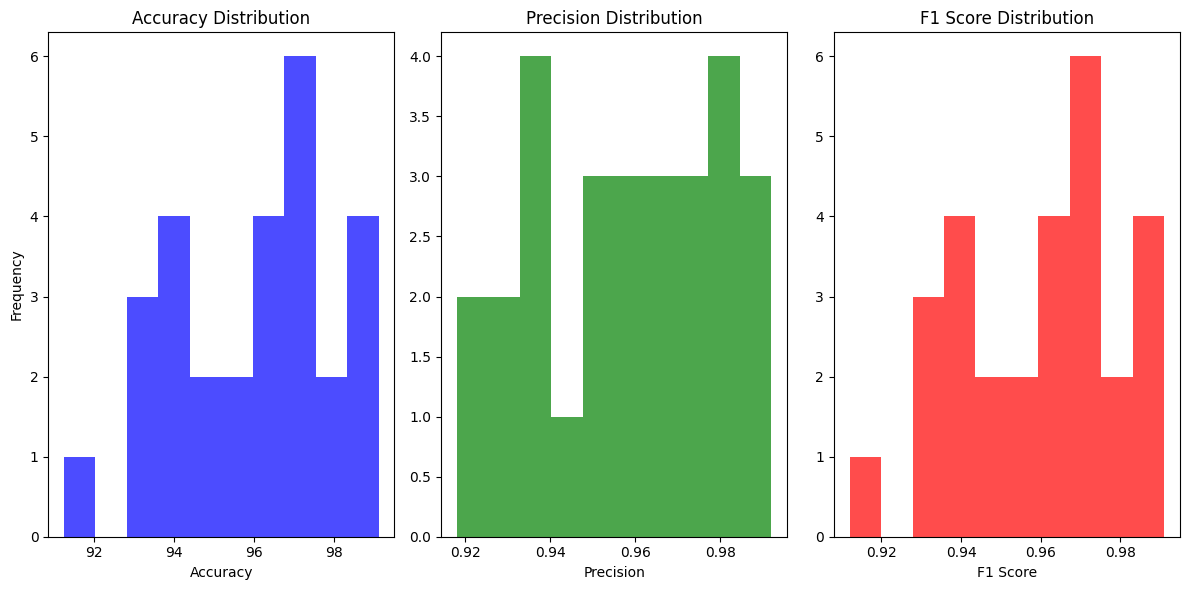

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy arrays for easier manipulation
Accuracy = np.array(Accuracy)
Precision = np.array(Precision)
F1_Score = np.array(F1_Score)

# Calculate basic statistics
def calculate_statistics(data):
    mean = np.mean(data)
    median = np.median(data)
    std_dev = np.std(data)
    return mean, median, std_dev

accuracy_stats = calculate_statistics(Accuracy)
precision_stats = calculate_statistics(Precision)
f1_score_stats = calculate_statistics(F1_Score)

# Print statistics
print("Accuracy - Mean: {:.2f}, Median: {:.2f}, Std Dev: {:.2f}".format(*accuracy_stats))
print("Precision - Mean: {:.2f}, Median: {:.2f}, Std Dev: {:.2f}".format(*precision_stats))
print("F1 Score - Mean: {:.2f}, Median: {:.2f}, Std Dev: {:.2f}".format(*f1_score_stats))

# Plotting
plt.figure(figsize=(12, 6))

# Accuracy
plt.subplot(1, 3, 1)
plt.hist(Accuracy, bins=10, color='blue', alpha=0.7)
plt.title('Accuracy Distribution')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')

# Precision
plt.subplot(1, 3, 2)
plt.hist(Precision, bins=10, color='green', alpha=0.7)
plt.title('Precision Distribution')
plt.xlabel('Precision')

# F1 Score
plt.subplot(1, 3, 3)
plt.hist(F1_Score, bins=10, color='red', alpha=0.7)
plt.title('F1 Score Distribution')
plt.xlabel('F1 Score')

plt.tight_layout()
plt.show()

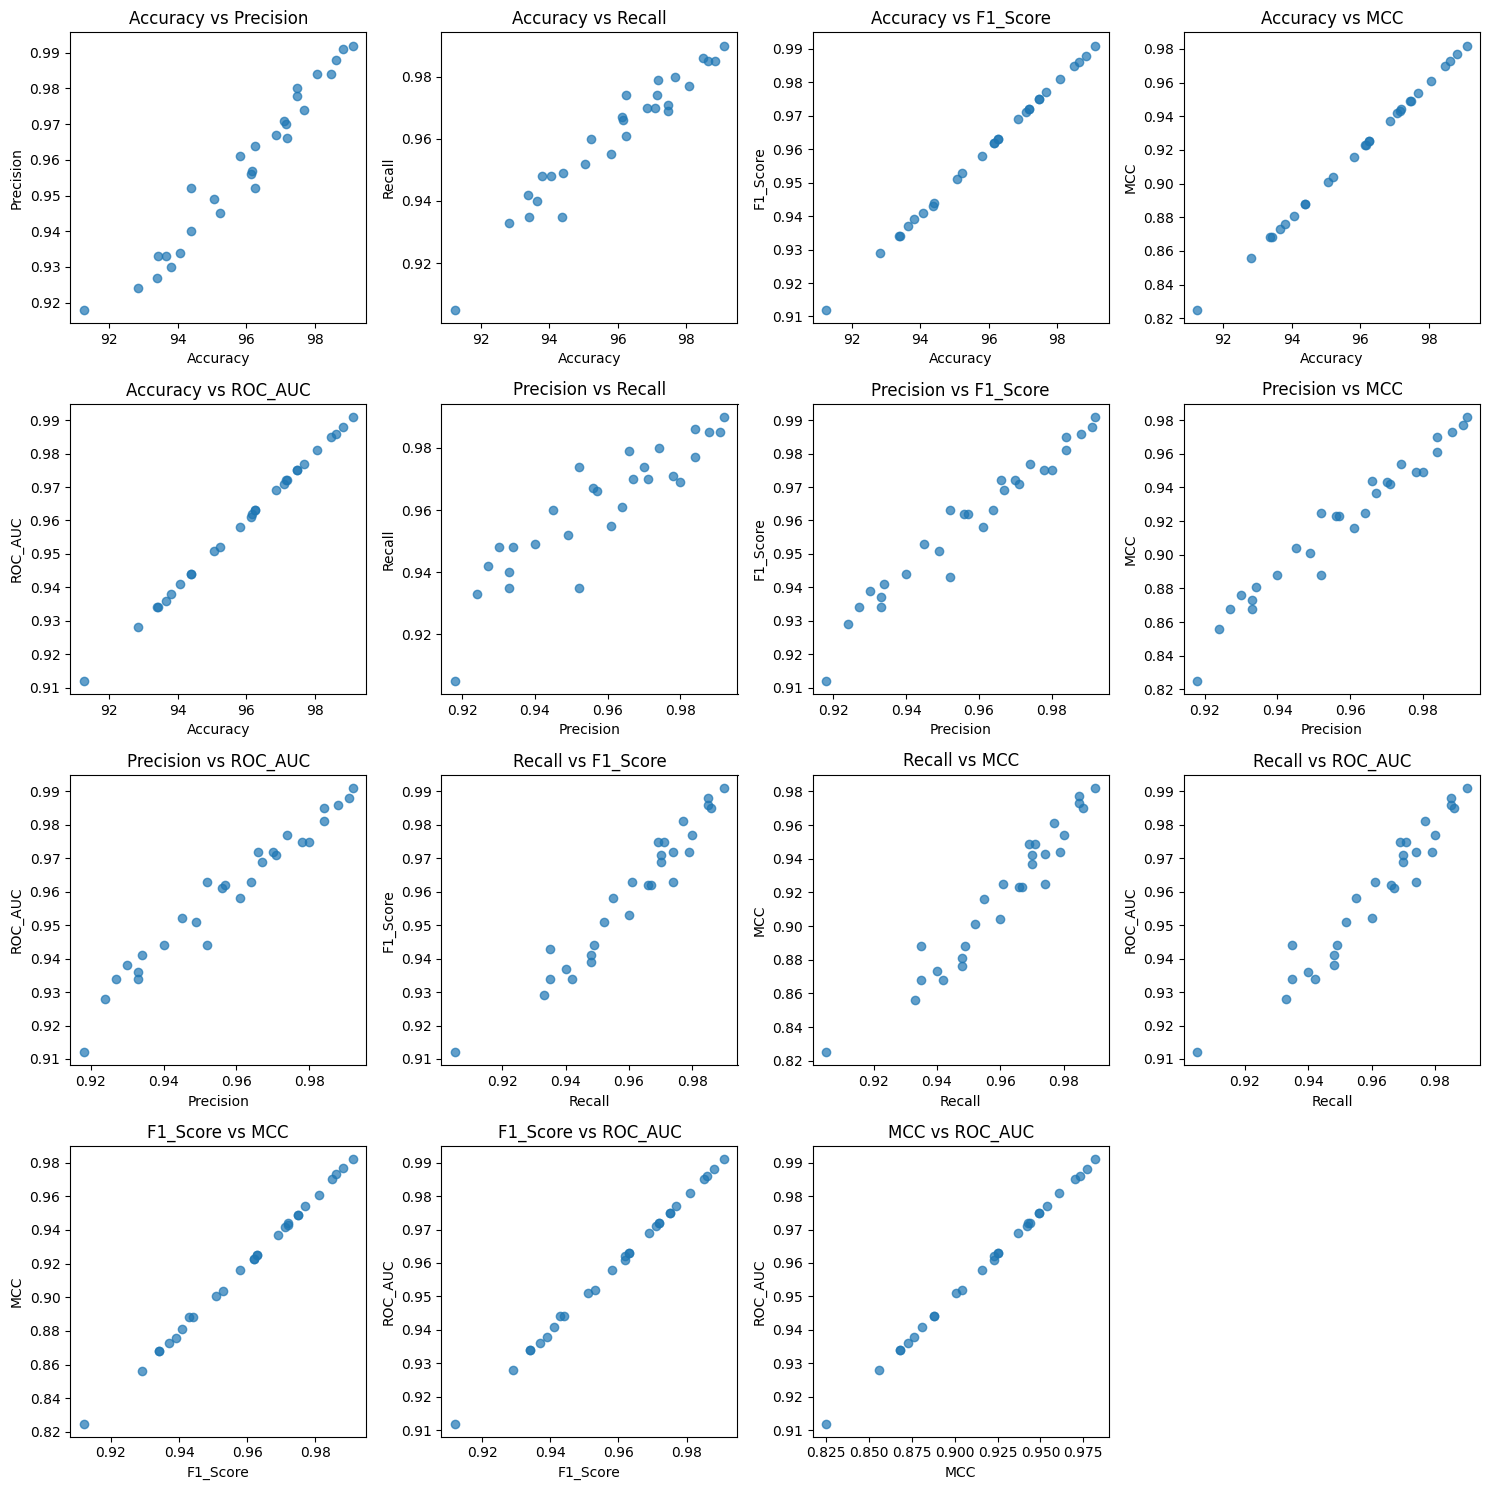

In [ ]:
import pandas as pd

# Data
data = {
    "Accuracy": [92.821, 98.072, 97.088, 93.802, 97.474, 96.258, 96.14, 96.257, 97.187, 97.163, 93.419, 99.109, 97.683, 95.219, 93.379, 98.832, 95.062, 91.247, 98.627, 96.865, 93.647, 94.069, 95.809, 96.159, 94.392, 94.378, 98.481, 97.472],
    "Precision": [0.924, 0.984, 0.971, 0.93, 0.978, 0.964, 0.956, 0.952, 0.966, 0.97, 0.933, 0.992, 0.974, 0.945, 0.927, 0.991, 0.949, 0.918, 0.988, 0.967, 0.933, 0.934, 0.961, 0.957, 0.94, 0.952, 0.984, 0.98],
    "Recall": [0.933, 0.977, 0.97, 0.948, 0.971, 0.961, 0.967, 0.974, 0.979, 0.974, 0.935, 0.99, 0.98, 0.96, 0.942, 0.985, 0.952, 0.905, 0.985, 0.97, 0.94, 0.948, 0.955, 0.966, 0.949, 0.935, 0.986, 0.969],
    "F1_Score": [0.929, 0.981, 0.971, 0.939, 0.975, 0.963, 0.962, 0.963, 0.972, 0.972, 0.934, 0.991, 0.977, 0.953, 0.934, 0.988, 0.951, 0.912, 0.986, 0.969, 0.937, 0.941, 0.958, 0.962, 0.944, 0.943, 0.985, 0.975],
    "MCC": [0.856, 0.961, 0.942, 0.876, 0.949, 0.925, 0.923, 0.925, 0.944, 0.943, 0.868, 0.982, 0.954, 0.904, 0.868, 0.977, 0.901, 0.825, 0.973, 0.937, 0.873, 0.881, 0.916, 0.923, 0.888, 0.888, 0.97, 0.949],
    "ROC_AUC": [0.928, 0.981, 0.971, 0.938, 0.975, 0.963, 0.961, 0.963, 0.972, 0.972, 0.934, 0.991, 0.977, 0.952, 0.934, 0.988, 0.951, 0.912, 0.986, 0.969, 0.936, 0.941, 0.958, 0.962, 0.944, 0.944, 0.985, 0.975]
}

df = pd.DataFrame(data)

# Plotting
pairs = [
    ("Accuracy", "Precision"),
    ("Accuracy", "Recall"),
    ("Accuracy", "F1_Score"),
    ("Accuracy", "MCC"),
    ("Accuracy", "ROC_AUC"),
    ("Precision", "Recall"),
    ("Precision", "F1_Score"),
    ("Precision", "MCC"),
    ("Precision", "ROC_AUC"),
    ("Recall", "F1_Score"),
    ("Recall", "MCC"),
    ("Recall", "ROC_AUC"),
    ("F1_Score", "MCC"),
    ("F1_Score", "ROC_AUC"),
    ("MCC", "ROC_AUC")
]

plt.figure(figsize=(15, 15))

for i, pair in enumerate(pairs, 1):
    plt.subplot(4, 4, i)
    plt.scatter(df[pair[0]], df[pair[1]], alpha=0.7)
    plt.xlabel(pair[0])
    plt.ylabel(pair[1])
    plt.title(f'{pair[0]} vs {pair[1]}')

plt.tight_layout()
plt.show()


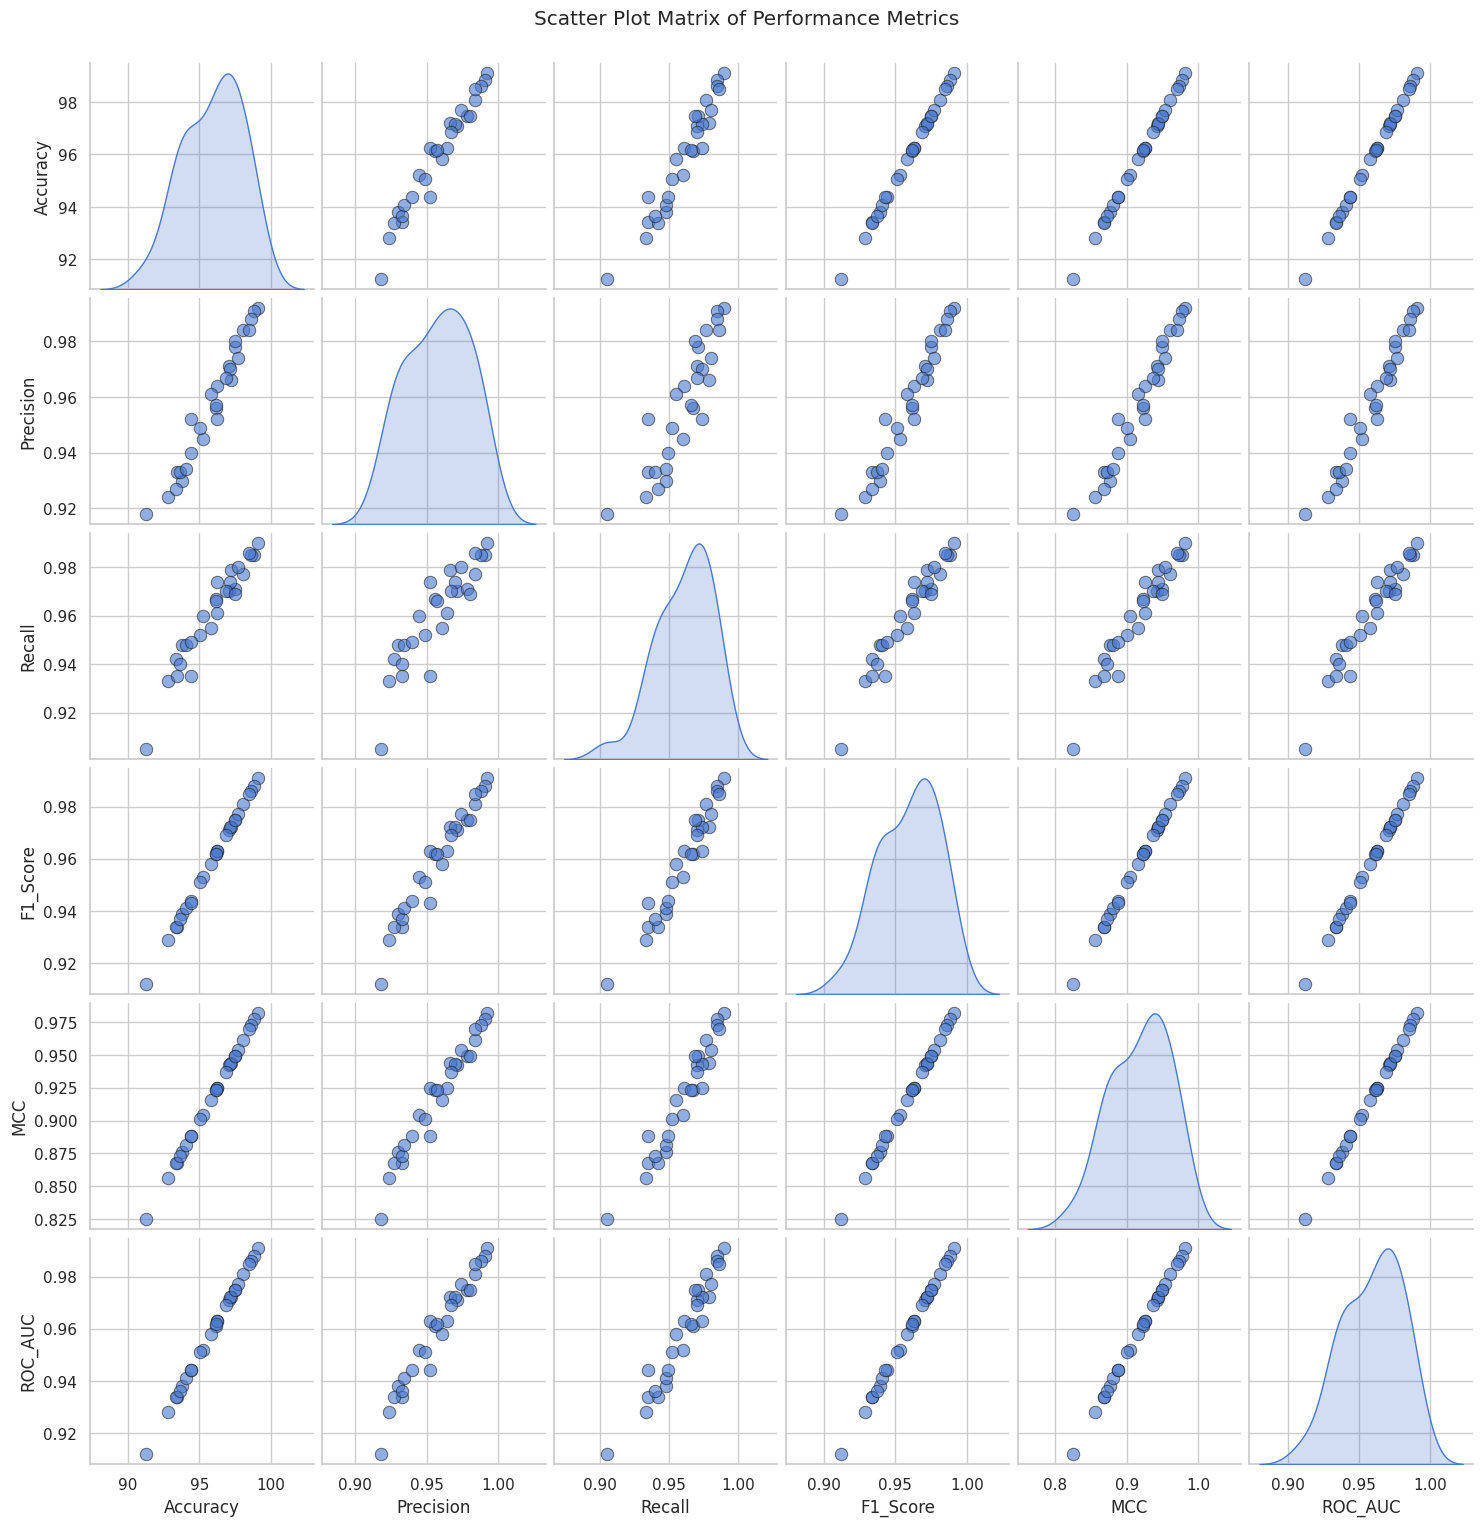

In [ ]:

import seaborn as sns

# Setting up the aesthetics for the scatter plot matrix
sns.set(style="whitegrid", palette="muted")

# Creating a pair plot (scatter plot matrix) of the metrics
pair_plot = sns.pairplot(df, diag_kind='kde', plot_kws={'alpha':0.6, 's':80, 'edgecolor':'k'})

# Enhancing the pair plot with titles
pair_plot.fig.suptitle("Scatter Plot Matrix of Performance Metrics", y=1.02)

# Display the plot
plt.show()

